# GrIS elevation band melt SEB causality

Author: Ziqi Yin

Last modified: 2026 Jun 2

Description: Causal inference of Greenland Ice Sheet summer surface melt
- Method: PCMCI+
- Period: 1975-2014
- Frequency: monthly
- Region: elevation band (< 1000m)
- Variables: SWn, LWn, SH, LH
- Source: fully coupled CESM2 large ensemble 50 cmip6 members

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

import sys
home_dir = '/glade/work/ziqiyin/'
sys.path.insert(0, home_dir)
from copy import deepcopy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')

import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

import cartopy
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PolyCollection
from collections import Counter, defaultdict

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/ziqiyin/conda-envs/my-npl-202306a/share/proj failed


In [2]:
# Function to remove seasonal mean and divide by seasonal standard deviation
def anomalize(dataseries, divide_by_std=True, reference_bounds=None, cycle_length=12, return_cycle=False):
    if reference_bounds is None:
        reference_bounds = (0, len(dataseries))

    anomaly = np.copy(dataseries)
    for t in range(cycle_length):
        if return_cycle:
            anomaly[t::cycle_length] = dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
        else:
            anomaly[t::cycle_length] -= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
            if divide_by_std:
                anomaly[t::cycle_length] /= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].std(axis=0)
    return anomaly

In [3]:
# Set Polar Sterographic Projection definition
polar_stereographic = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-45.0,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70.0,
    globe=ccrs.Globe('WGS84')
)

In [4]:
dates = pd.date_range("1970-01-01", periods=45*12, freq='M')

In [5]:
## Area
Re = 6371.22 * 1e3 #[m]

f09_mask_file3 = '/glade/p/cesmdata/cseg/inputdata/share/domains/domain.lnd.fv0.9x1.25_gx1v7.151020.nc'
f09_area = xr.open_dataset(f09_mask_file3)['area'] #[Radian2]
f09_area_Arctic = f09_area.where(f09_area.yc > 60).values * Re**2
f09_area = f09_area.values * Re**2

In [6]:
## Mask
# Generate Greenland mask
f09_mask_file1 = '/glade/work/aherring/grids/uniform-res/f09/clm_surfdata_5_0/surfdata_f09_hist_78pfts_CMIP6_simyr1850_c200429.nc'
f09_GrIS_mask0 = xr.open_dataset(f09_mask_file1)['GLACIER_REGION']
f09_GrIS_mask0 = xr.where(f09_GrIS_mask0==2, 1, np.nan)

# Land fraction of grid cell
f09_mask_file3 = '/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001/lnd/proc/tseries/month_1/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001.clm2.h0.RAIN.000101-005012.nc'
f09_land_frac = xr.open_dataset(f09_mask_file3)['landfrac'] #fraction of grid cell that is active

In [7]:
Melt_dataset = np.zeros((50,40*12))
SWn_dataset = np.zeros((50,40*12))
LWn_dataset = np.zeros((50,40*12))
SH_dataset = np.zeros((50,40*12))
LH_dataset = np.zeros((50,40*12))
GHF_dataset = np.zeros((50,40*12))

In [8]:
## Elevation
data_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/atm/proc/tseries/month_1/'
PHIS = xr.open_dataset(data_dir+'PHIS/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.PHIS.197001-197912.nc')['PHIS'][0]

data_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/lnd/proc/tseries/month_1/'
f09_lnd_lon = xr.open_dataset(data_dir+'SNOW/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.clm2.h0.SNOW.197001-197912.nc')['SNOW'].lon
f09_lnd_lat = xr.open_dataset(data_dir+'SNOW/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.clm2.h0.SNOW.197001-197912.nc')['SNOW'].lat

PHIS['lon'] = f09_lnd_lon.values
PHIS['lat'] = f09_lnd_lat.values

g = 9.80616 #[m/s2]

## Read and calculate

In [11]:
data_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/lnd/proc/tseries/month_1/'

namelist = ['1001.001', '1021.002', '1041.003', '1061.004', '1081.005', '1101.006', '1121.007', '1141.008', '1161.009', '1181.010',
            '1231.001', '1231.002', '1231.003', '1231.004', '1231.005', '1231.006', '1231.007', '1231.008', '1231.009', '1231.010',
            '1251.001', '1251.002', '1251.003', '1251.004', '1251.005', '1251.006', '1251.007', '1251.008', '1251.009', '1251.010',
            '1281.001', '1281.002', '1281.003', '1281.004', '1281.005', '1281.006', '1281.007', '1281.008', '1281.009', '1281.010',
            '1301.001', '1301.002', '1301.003', '1301.004', '1301.005', '1301.006', '1301.007', '1301.008', '1301.009', '1301.010']
#period = ['194001-194912', '195001-195912', '196001-196912', '197001-197912', '198001-198912', '199001-199912', '200001-200912', '201001-201412']
period = ['197001-197912', '198001-198912', '199001-199912', '200001-200912', '201001-201412']

for index, num in enumerate(namelist):

    #RAIN_monthly_list = []
    #SNOW_monthly_list = []
    QICE_MELT_monthly_list = []
    QSNOMELT_monthly_list = []
    #QFLX_EVAP_TOT_monthly_list = []
    #QRUNOFF_monthly_list = []
    FSDS_monthly_list = []
    FSR_monthly_list = []
    FLDS_monthly_list = []
    FIRE_monthly_list = []
    FSH_monthly_list = []
    EFLX_LH_TOT_monthly_list = []
    PCT_LANDUNIT_monthly_list = []
    FSM_monthly_list = []
    FGR_monthly_list = []
    
    for j in period:
        #RAIN_monthly_p = xr.open_dataset(data_dir+'RAIN_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.RAIN_ICE.'+j+'.nc')['RAIN_ICE'] #[mm/s]
        #SNOW_monthly_p = xr.open_dataset(data_dir+'SNOW_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.SNOW_ICE.'+j+'.nc')['SNOW_ICE']
        QICE_MELT_monthly_p = xr.open_dataset(data_dir+'QICE_MELT/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.QICE_MELT.'+j+'.nc')['QICE_MELT']
        QSNOMELT_monthly_p = xr.open_dataset(data_dir+'QSNOMELT_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.QSNOMELT_ICE.'+j+'.nc')['QSNOMELT_ICE']
        #QFLX_EVAP_TOT_monthly_p = xr.open_dataset(data_dir+'QFLX_EVAP_TOT/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.QFLX_EVAP_TOT.'+j+'.nc')['QFLX_EVAP_TOT']
        #QRUNOFF_monthly_p = xr.open_dataset(data_dir+'QRUNOFF_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.QRUNOFF_ICE.'+j+'.nc')['QRUNOFF_ICE']
        FSDS_monthly_p = xr.open_dataset(data_dir+'FSDS/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.FSDS.'+j+'.nc')['FSDS']
        FSR_monthly_p = xr.open_dataset(data_dir+'FSR_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.FSR_ICE.'+j+'.nc')['FSR_ICE']
        FLDS_monthly_p = xr.open_dataset(data_dir+'FLDS_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.FLDS_ICE.'+j+'.nc')['FLDS_ICE']
        FIRE_monthly_p = xr.open_dataset(data_dir+'FIRE_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.FIRE_ICE.'+j+'.nc')['FIRE_ICE']
        FSH_monthly_p = xr.open_dataset(data_dir+'FSH_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.FSH_ICE.'+j+'.nc')['FSH_ICE']
        EFLX_LH_TOT_monthly_p = xr.open_dataset(data_dir+'EFLX_LH_TOT_ICE/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.EFLX_LH_TOT_ICE.'+j+'.nc')['EFLX_LH_TOT_ICE']
        PCT_LANDUNIT_monthly_p = xr.open_dataset(data_dir+'PCT_LANDUNIT/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.PCT_LANDUNIT.'+j+'.nc')['PCT_LANDUNIT'][:,3,:,:]
        FSM_monthly_p = xr.open_dataset(data_dir+'FSM/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.FSM.'+j+'.nc')['FSM']
        FGR_monthly_p = xr.open_dataset(data_dir+'FGR/b.e21.BHISTcmip6.f09_g17.LE2-'+num+'.clm2.h0.FGR.'+j+'.nc')['FGR']

        #RAIN_monthly_list.append(RAIN_monthly_p)
        #SNOW_monthly_list.append(SNOW_monthly_p)
        QICE_MELT_monthly_list.append(QICE_MELT_monthly_p)
        QSNOMELT_monthly_list.append(QSNOMELT_monthly_p)
        #QFLX_EVAP_TOT_monthly_list.append(QFLX_EVAP_TOT_monthly_p)
        #QRUNOFF_monthly_list.append(QRUNOFF_monthly_p)
        FSDS_monthly_list.append(FSDS_monthly_p)
        FSR_monthly_list.append(FSR_monthly_p)
        FLDS_monthly_list.append(FLDS_monthly_p)
        FIRE_monthly_list.append(FIRE_monthly_p)
        FSH_monthly_list.append(FSH_monthly_p)
        EFLX_LH_TOT_monthly_list.append(EFLX_LH_TOT_monthly_p)
        PCT_LANDUNIT_monthly_list.append(PCT_LANDUNIT_monthly_p)
        FSM_monthly_list.append(FSM_monthly_p)
        FGR_monthly_list.append(FGR_monthly_p)

    #RAIN_monthly = xr.concat(RAIN_monthly_list, dim='time')
    #SNOW_monthly = xr.concat(SNOW_monthly_list, dim='time')
    QICE_MELT_monthly = xr.concat(QICE_MELT_monthly_list, dim='time')
    QSNOMELT_monthly = xr.concat(QSNOMELT_monthly_list, dim='time')
    #QFLX_EVAP_TOT_monthly = xr.concat(QFLX_EVAP_TOT_monthly_list, dim='time')
    #QRUNOFF_monthly = xr.concat(QRUNOFF_monthly_list, dim='time')
    FSDS_monthly = xr.concat(FSDS_monthly_list, dim='time')
    FSR_monthly = xr.concat(FSR_monthly_list, dim='time')
    FLDS_monthly = xr.concat(FLDS_monthly_list, dim='time')
    FIRE_monthly = xr.concat(FIRE_monthly_list, dim='time')
    FSH_monthly = xr.concat(FSH_monthly_list, dim='time')
    EFLX_LH_TOT_monthly = xr.concat(EFLX_LH_TOT_monthly_list, dim='time')
    PCT_LANDUNIT_monthly = xr.concat(PCT_LANDUNIT_monthly_list, dim='time')
    FSM_monthly = xr.concat(FSM_monthly_list, dim='time')
    FGR_monthly = xr.concat(FGR_monthly_list, dim='time')

    #RAIN_monthly['time'] = dates
    #SNOW_monthly['time'] = dates
    QICE_MELT_monthly['time'] = dates
    QSNOMELT_monthly['time'] = dates
    #QFLX_EVAP_TOT_monthly['time'] = dates
    #QRUNOFF_monthly['time'] = dates
    FSDS_monthly['time'] = dates
    FSR_monthly['time'] = dates
    FLDS_monthly['time'] = dates
    FIRE_monthly['time'] = dates
    FSH_monthly['time'] = dates
    EFLX_LH_TOT_monthly['time'] = dates
    PCT_LANDUNIT_monthly['time'] = dates
    FSM_monthly['time'] = dates
    FGR_monthly['time'] = dates

    #RAIN_monthly = RAIN_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    #SNOW_monthly = SNOW_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    QICE_MELT_monthly = QICE_MELT_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    QSNOMELT_monthly = QSNOMELT_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    #QFLX_EVAP_TOT_monthly = QFLX_EVAP_TOT_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    #QRUNOFF_monthly = QRUNOFF_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    FSDS_monthly = FSDS_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    FSR_monthly = FSR_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    FLDS_monthly = FLDS_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    FIRE_monthly = FIRE_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    FSH_monthly = FSH_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    EFLX_LH_TOT_monthly = EFLX_LH_TOT_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    PCT_LANDUNIT_monthly = PCT_LANDUNIT_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    FSM_monthly = FSM_monthly.sel(time=slice('1975-01-01','2014-12-31'))
    FGR_monthly = FGR_monthly.sel(time=slice('1975-01-01','2014-12-31'))

    # GrIS mask
    f09_glacier_frac = PCT_LANDUNIT_monthly
    f09_GrIS_mask = f09_GrIS_mask0.values * f09_glacier_frac * f09_land_frac.values / 100

    # Elevation zone
    f09_elev = PHIS / g #[m]
    f09_GrIS_mask = f09_GrIS_mask.where(f09_elev<=1000)

    if num == '1001.001':
        f09_GrIS_mask_n1 = f09_GrIS_mask

    # Calculate
    int_QICE_MELT_monthly = (QICE_MELT_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat'])
    int_QSNOMELT_monthly = (QSNOMELT_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat'])
    int_MELT_monthly = int_QICE_MELT_monthly + int_QSNOMELT_monthly
    int_SWn_monthly = ((FSDS_monthly - FSR_monthly) * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_LWn_monthly = ((FLDS_monthly - FIRE_monthly) * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_SH_monthly = -(FSH_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_LH_monthly = -(EFLX_LH_TOT_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_GHF_monthly = -((FGR_monthly - FSM_monthly - QICE_MELT_monthly * 3.34e5) * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])

    Melt_dataset[index,:] = int_MELT_monthly.values *(3600*24)/1e12 #[Gt/day]
    SWn_dataset[index,:] = int_SWn_monthly.values
    LWn_dataset[index,:] = int_LWn_monthly.values
    SH_dataset[index,:] = int_SH_monthly.values
    LH_dataset[index,:] = int_LH_monthly.values
    GHF_dataset[index,:] = int_GHF_monthly.values
    print(index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


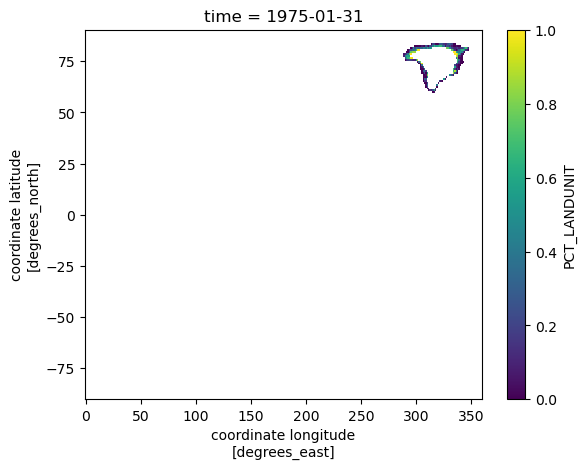

In [10]:
f09_GrIS_mask[0].plot();

## Save

In [12]:
time = int_SWn_monthly.time
ensemble = np.arange(1,51)

dataset = xr.Dataset(
    {
        "Melt": (("ensemble", "time"), Melt_dataset, {"units": "Gt/day"}),
        "SWn": (("ensemble", "time"), SWn_dataset, {"units": "W/m^2"}),
        "LWn": (("ensemble", "time"), LWn_dataset, {"units": "W/m^2"}),
        "SH": (("ensemble", "time"), SH_dataset, {"units": "W/m^2"}),
        "LH": (("ensemble", "time"), LH_dataset, {"units": "W/m^2"}),
        "GHF": (("ensemble", "time"), GHF_dataset, {"units": "W/m^2"}),
    },
    coords={
        "time": time,
        "ensemble": ensemble,
    }
)

In [13]:
dataset.to_netcdf("time_series_LENS2_int_Melt_SEB_elevlt1000_ICEall_monthly_1975_2014.nc")

## Data pre-processing

The next question is about stationarity. A trend and seasonal cycle can introduce non-stationary dependencies that cannot be explained causally, that is, can act as confounders. Hence, as pre-processing steps, the trend and seasonal cycle are removed by first substracting both the trend (for example, caused by greenhouse gas forcing) and the seasonal cycle and then dividing by the seasonal variance. The length scale of the Gaussian kernel used for finding the long-term trend is assumed to be decadal ($15$ years). 

Further, considering the regime behavior of the system as explained above, only the summer months June to August are considered. On a technical level, this selection of considered time periods is achieved by applying a so-called mask (also see [masking tutorial](https://github.com/jakobrunge/tigramite/blob/master/tutorials/dataset_challenges/tigramite_tutorial_missing_masking.ipynb) in tigramite).

More specifically, here the mask is such that samples for all the variables at time $t$ can only come from Jun-Aug, while samples for the times $t-1$ and $t-2$ can also come from outside this mask.

In [14]:
def process_prepare_pcmci(int_vars,
                          remove_seasonal_cycle=True,
                          add_mask=True,
                          mask_period=[5, 6, 7],
                          detrend_by_month=True,
                          divide_by_std=True,
                          smooth_width_years=15):

    # Stack arrays in sequence vertically (row wise)
    data = np.vstack((
        int_vars['Melt'].values,
        int_vars['SWn'].values,
        int_vars['LWn'].values,
        int_vars['SH'].values,
        int_vars['LH'].values,
    )).T
    T, N = data.shape

    # Variable names used throughout
    var_names = ['Melt', 'SWn', 'LWn', 'SH', 'LH']

    cycle_length = 12  # monthly data

    # ---- 1) Detrending (global OR month-wise) ----
    if detrend_by_month:
        # Month-wise detrending: smooth each calendar-month subseries separately
        smoothdata_here = np.full_like(data, np.nan, dtype=float)
        data_here       = np.full_like(data, np.nan, dtype=float)

        for m in range(cycle_length):  # m=0..11
            idx = np.arange(m, T, cycle_length)   # all samples for month m
            sub = np.copy(data[idx, :])           # (n_years, N)

            if sub.shape[0] < 3:
                # too short to smooth meaningfully
                smooth_sub = np.zeros_like(sub)
                resid_sub  = sub
            else:
                # For month-subseries sampled yearly, 15-year smoothing => smooth_width=15
                smooth_sub = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                       kernel='gaussian', residuals=False)
                resid_sub  = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                       kernel='gaussian', residuals=True)

            smoothdata_here[idx, :] = smooth_sub
            data_here[idx, :]       = resid_sub

    else:
        # Original global detrending: 15 years * 12 months
        smooth_width = smooth_width_years * cycle_length
        smoothdata_here = pp.smooth(np.copy(data), smooth_width=smooth_width,
                                    kernel='gaussian', residuals=False)
        data_here = pp.smooth(np.copy(data), smooth_width=smooth_width,
                              kernel='gaussian', residuals=True)

    # ---- 2) Remove seasonal mean and divide by seasonal standard deviation ----
    seasonal_cycle = anomalize(np.copy(data_here), cycle_length=cycle_length, return_cycle=True)
    smoothdata_here = smoothdata_here + seasonal_cycle

    if remove_seasonal_cycle:
        data_here = anomalize(data_here, cycle_length=cycle_length, divide_by_std=divide_by_std)

    # ---- 3) Construct mask (select only JJA at time t; mask_type='y') ----
    if add_mask:
        mask = np.ones(data.shape, dtype='bool')
        for i in mask_period:
            mask[i::cycle_length, :] = False
    else:
        mask = None

    # ---- 4) Tigramite DataFrame + PCMCI ----
    dataframe = pp.DataFrame(data_here, mask=mask, var_names=var_names, missing_flag=999.)

    robustparcorr = RobustParCorr(significance='analytic', mask_type='y')
    pcmci = PCMCI(
        dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0
    )

    return pcmci

## PCMCI+ causal discovery

Here, we choose ``tau_max=12`` for PCMCI. The other main parameter is ``pc_alpha`` which sets the significance level in the condition-selection step. The parameter ``alpha_level=0.05`` indicates that we threshold the resulting p-value matrix at this significance level to obtain the graph.

In the process graph, the node color denotes the auto-MCI value (the link coefficient of the lag-1 autocorrelation links) and the link colors the cross-MCI value (the link coefficients or edge weight). If links occur at multiple lags between two variables, the link color denotes the strongest one and the label lists all significant lags in order of their strength. Additionally, setting ``show_autodependency_lags=True`` will display the significant auto dependencies below the respective node labels. 

You can adjust the size and aspect ratio of nodes with `node_size` and `node_aspect` parameters, and also modify many other properties, see the parameters of `plot_graph` and `plot_time_series_graph`.

In [15]:
file = home_dir+'2023-GrIS-melt-causality/CESM2_F09/historical/LENS2/elevation/time_series_LENS2_int_Melt_SEB_elevlt1000_ICEall_monthly_1975_2014.nc'

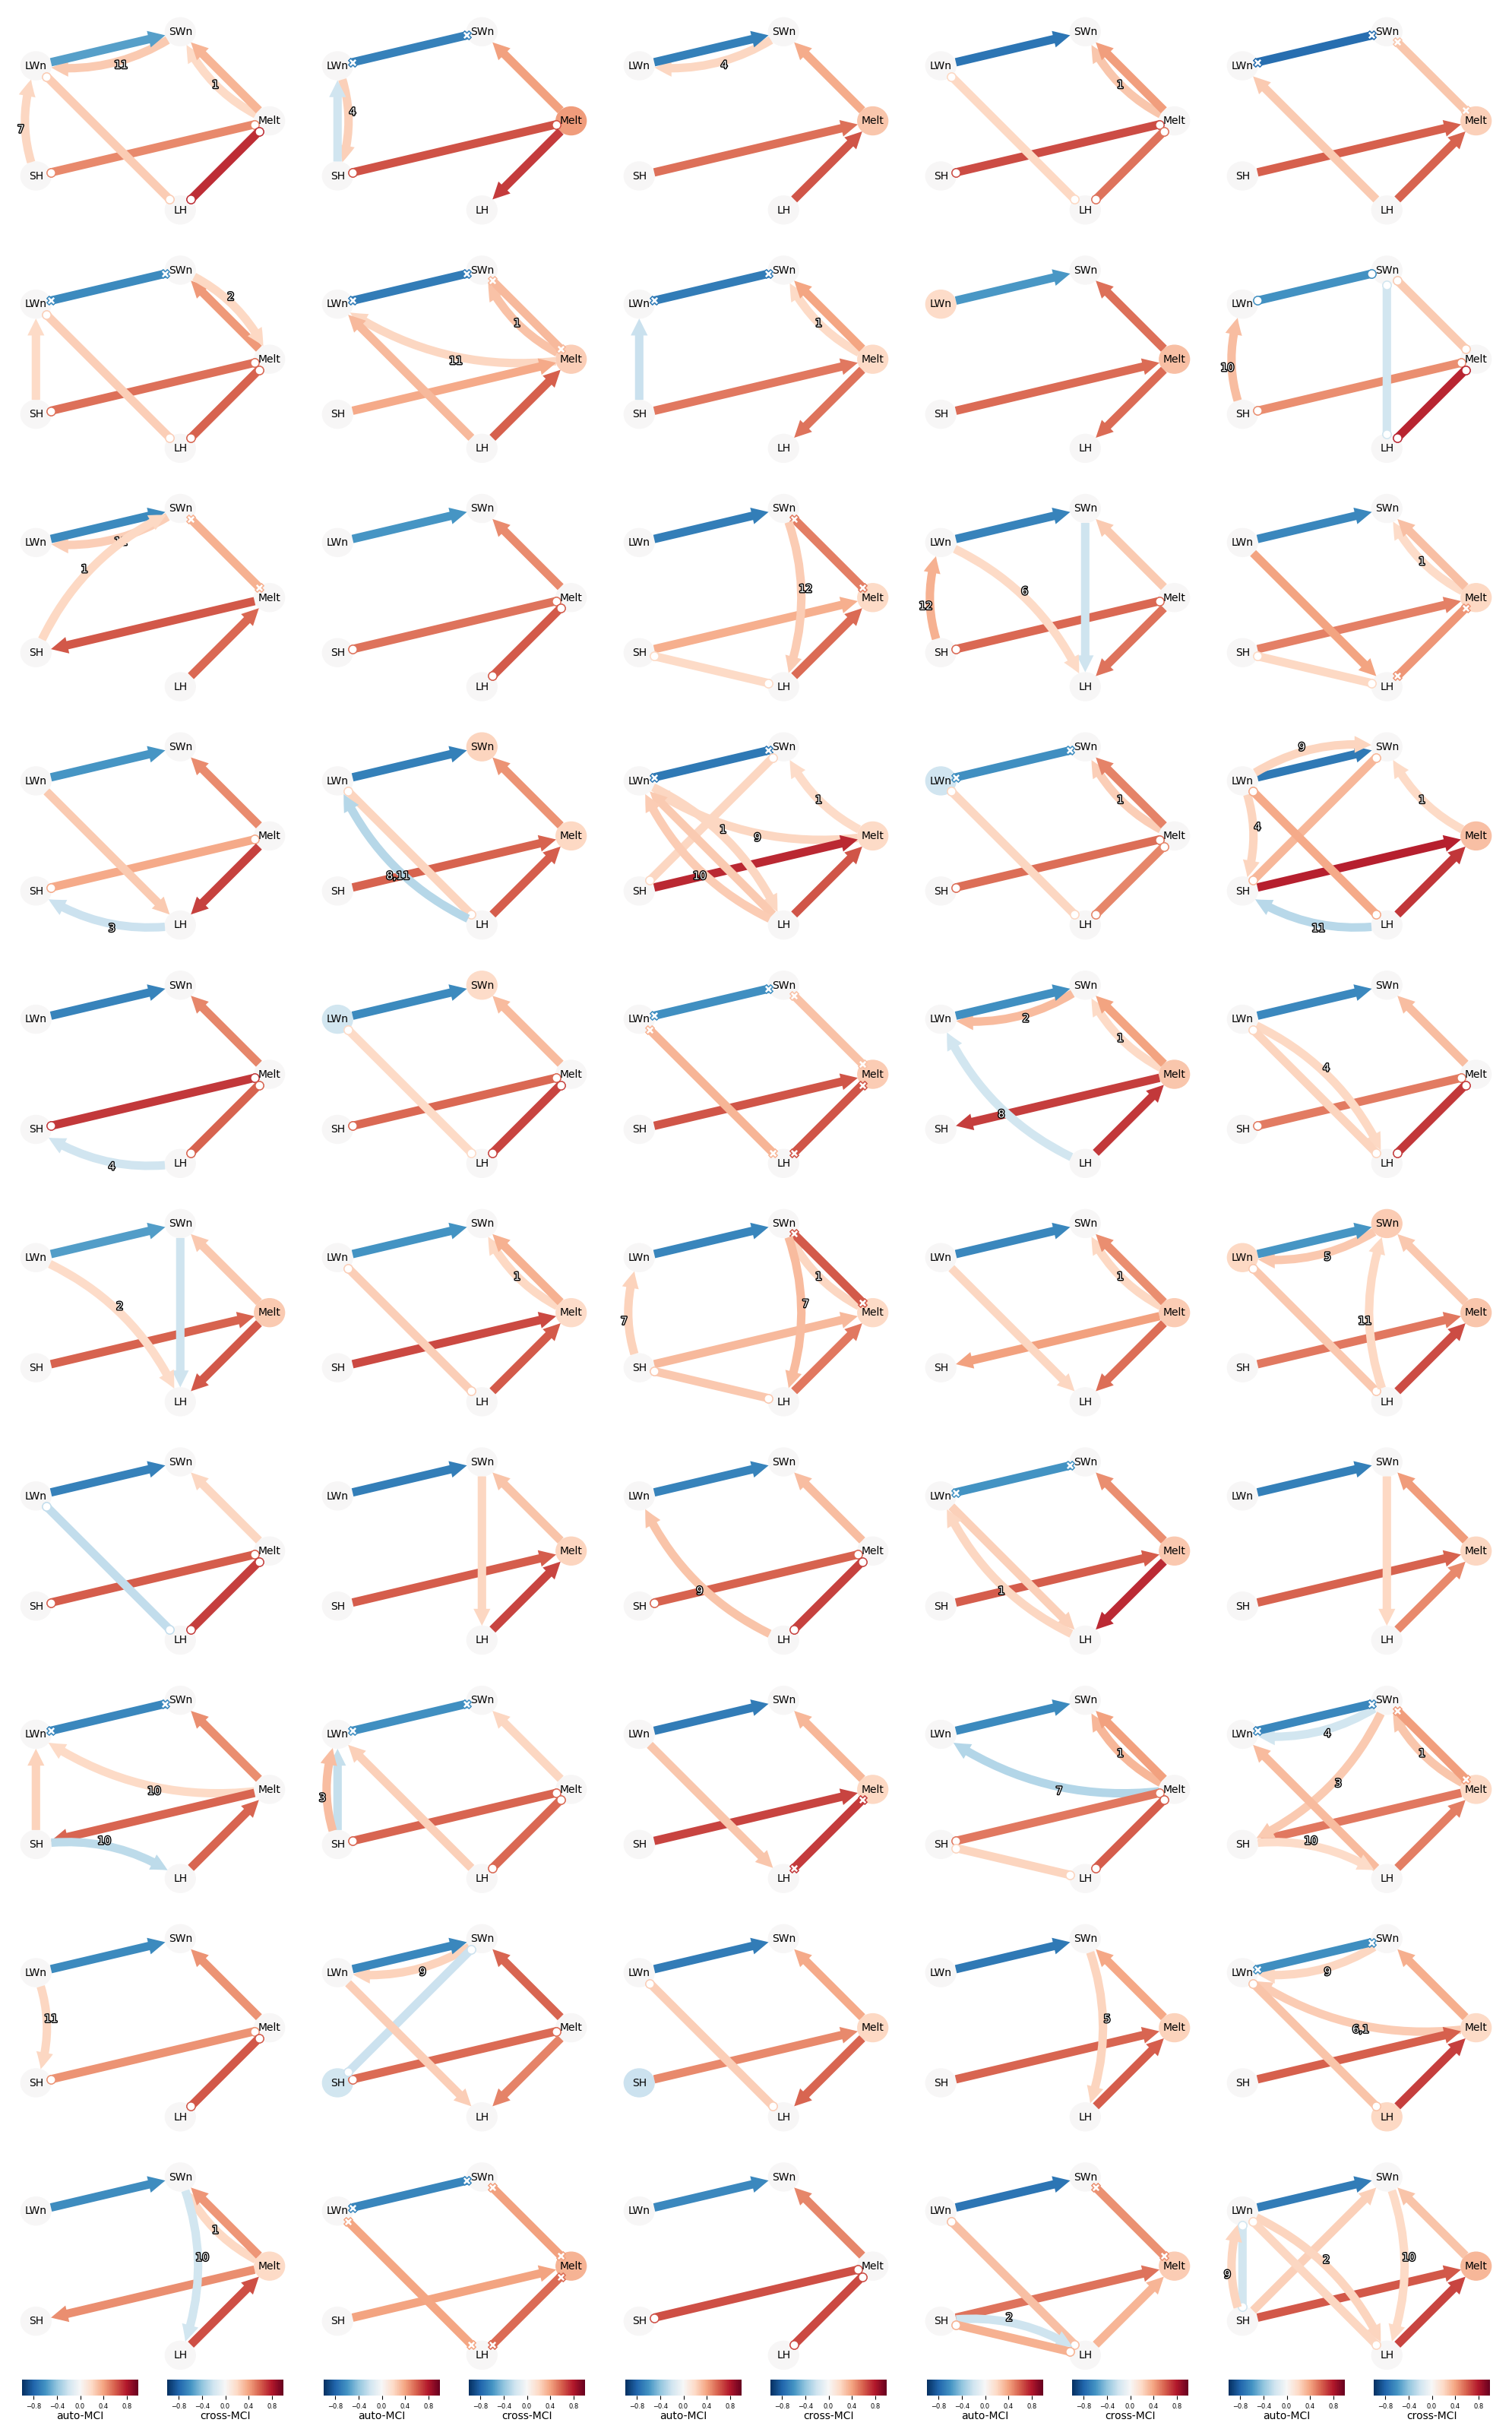

In [10]:
# Define a 10x5 grid layout for 50 subplots
# without seasonality, alpha=0.05
fig, axs = plt.subplots(10, 5, figsize=(20, 32))
axs = axs.flatten()  # Flatten to easily index subplots

for n in range(1,51):
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1975-01-01','2014-12-31'))

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=True, divide_by_std=True, smooth_width_years=15)

    # run without pcmci+ false-discovery rate contral
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=12, pc_alpha=0.05, contemp_collider_rule='conservative')

    if n <=45:
        tp.plot_graph(
            val_matrix=results['val_matrix'],
            graph=results['graph'],
            var_names=['Melt', 'SWn', 'LWn', 'SH', 'LH'],
            link_colorbar_label='cross-MCI',
            node_colorbar_label='auto-MCI',
            show_colorbar=False,
            fig_ax=(fig, axs[n-1])
            )
    else:
        tp.plot_graph(
            val_matrix=results['val_matrix'],
            graph=results['graph'],
            var_names=['Melt', 'SWn', 'LWn', 'SH', 'LH'],
            link_colorbar_label='cross-MCI',
            node_colorbar_label='auto-MCI',
            fig_ax=(fig, axs[n-1])
            )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/1975_2014/ICE/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax12_alpha0.05.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

### Aggregated graph

#### Most frequent link

##### with seasonal cycle, max_lag=12, pc_alpha=0.05

In [19]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.05
remove_seasonal_cycle=False

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [20]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [21]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

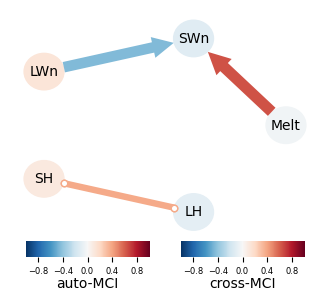

In [22]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### with seasonal cycle, max_lag=12, pc_alpha=0.1

In [23]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.1

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=False, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [24]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [25]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

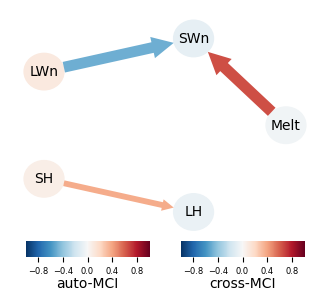

In [26]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### with seasonal cycle, max_lag=12, pc_alpha=None

In [27]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = None

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=False, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [28]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [29]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

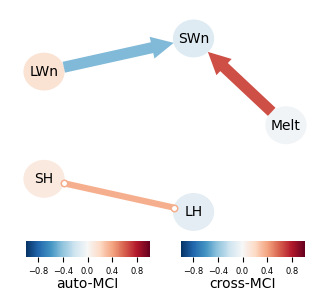

In [30]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=12, pc_alpha=0.05

In [31]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.05
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [32]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [33]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

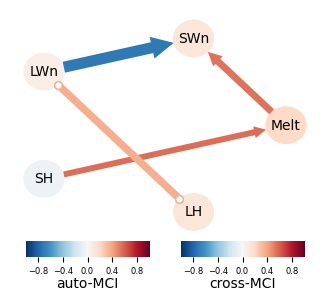

In [34]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [35]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv',
    digits=5,
)

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

In [12]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.1
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [13]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [14]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

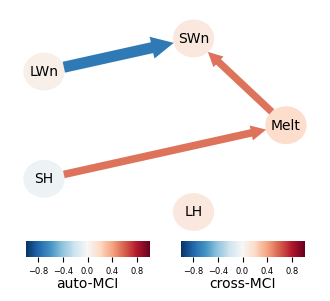

In [39]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [40]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv',
    digits=5,
)

In [20]:
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/1940_1969/'
save_name = plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.183230,0.0
1,Melt,SWn,0,-->,0.545780,23.0
2,Melt,SH,0,<--,0.543580,24.0
3,SWn,SWn,1,-->,0.106910,0.0
4,SWn,LWn,0,<--,-0.715120,35.0
5,LWn,LWn,1,-->,0.059308,0.0
6,SH,SH,1,-->,-0.050971,0.0
7,LH,LH,1,-->,0.108830,0.0


##### without seasonal cycle, max_lag=12, pc_alpha=None

In [41]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [42]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [43]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

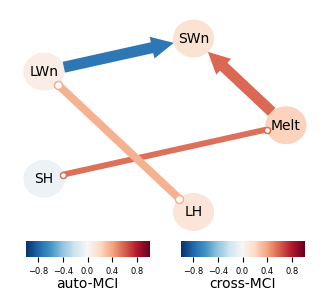

In [44]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [45]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv',
    digits=5,
)

##### without seasonal cycle, max_lag=3, pc_alpha=None

In [46]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 3 # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [47]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [48]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

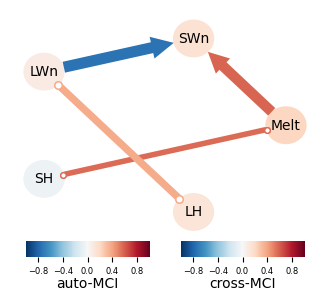

In [49]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=3, pc_alpha=0.1

In [50]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 3 # Maximum lag for PCMCI+
pc_alpha = 0.1
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [51]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [52]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

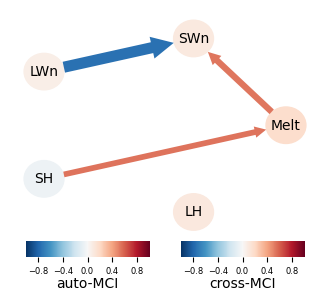

In [53]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=6, pc_alpha=None

In [54]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 6  # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [55]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [56]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

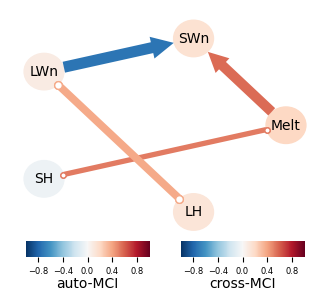

In [57]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=15, pc_alpha=None

In [58]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 15  # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1940-01-01','1969-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [59]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [60]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

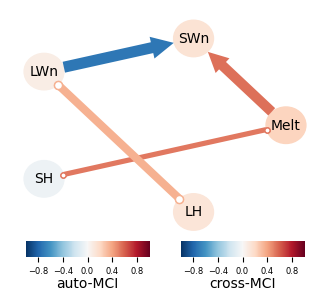

In [61]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_noseasonality_LENS2_1940_1969_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

### Aggregated graph, divided by std (corrected for significance of self-MCI)

##### without seasonal cycle, max_lag=12, pc_alpha=0.025

In [75]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.025
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1975-01-01','2014-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [76]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [77]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

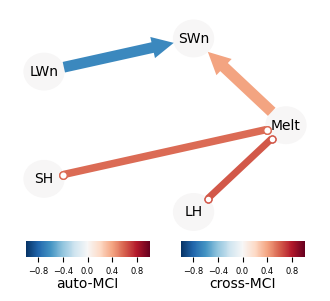

In [78]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/1975_2014/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [79]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [80]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.39872,37.0
2,Melt,SH,0,o-o,0.56328,25.0
3,Melt,LH,0,o-o,0.61919,23.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.64584,36.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [81]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

##### without seasonal cycle, max_lag=12, pc_alpha=0.05

In [16]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.05
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1975-01-01','2014-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [17]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [18]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

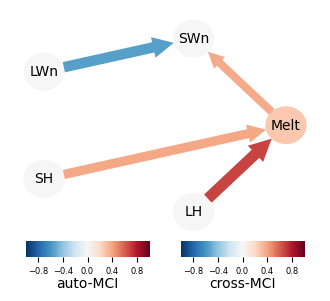

In [19]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/1975_2014/ICE/elevation/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_elevlt1000_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [20]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/elevation/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_elevlt1000_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [21]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/elevation/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_elevlt1000_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.26756,0.0
1,Melt,SWn,0,-->,0.37558,26.0
2,Melt,SH,0,<--,0.38515,30.0
3,Melt,LH,0,<--,0.67452,36.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.54699,34.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [22]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/elevation/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_elevlt1000_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

In [23]:
# ===== Save contemporaneous strengths (lag=0) for the most-frequent link type =====
pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}  # contemporaneous link encodings

# Infer number of members
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

def consolidate_type(t_ij, t_ji):
    """Pick a single contemporaneous type for this member between vars i and j."""
    # Prefer explicit types; if both present but mismatch, pick a stable rule:
    # If either is undirected, treat as undirected; else prefer '-->' or '<--' if present.
    if t_ij in valid_types and t_ji in valid_types:
        if ('o-o' in (t_ij, t_ji)) or ('x-x' in (t_ij, t_ji)):
            return 'o-o' if 'o-o' in (t_ij, t_ji) else 'x-x'
        # If both are directed but inconsistent, prefer t_ij (stable, deterministic)
        return t_ij
    if t_ij in valid_types:
        return t_ij
    if t_ji in valid_types:
        # Map the (j,i) direction into the canonical i–j viewpoint:
        # If (j,i) shows '-->' that means j→i, i.e., '<--' for (i,j)
        if t_ji == '-->':
            return '<--'
        if t_ji == '<--':
            return '-->'
        return t_ji  # 'o-o' or 'x-x'
    return ''  # no contemporaneous link detected

# Priority for final tie-break if needed
type_priority = ['-->', '<--', 'o-o', 'x-x']

out = {}
dir_counts = {}
mf_type_meta = {}
mf_type_counts = {}
mf_type_mean_strength = {}

for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    types_ij  = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji  = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    # Per-member consolidated type (one of '-->','<--','o-o','x-x','')
    cons_types = np.array(
        [consolidate_type(types_ij[k], types_ji[k]) for k in range(n_members)],
        dtype='U3'
    )

    # Count frequencies among *detected* types (exclude '')
    counts = {t: int(np.sum(cons_types == t)) for t in valid_types}

    # If no detections at all, keep all-NaN and record 'none'
    if sum(counts.values()) == 0:
        out[f'{a}_to_{b}_lag0_mostfreq'] = np.full(n_members, np.nan, dtype=float)
        mf_type_meta[f'{a}_{b}_mostfreq_type'] = 'none'
        mf_type_counts[f'{a}_{b}_counts'] = counts
        mf_type_mean_strength[f'{a}_{b}_type_means'] = {t: np.nan for t in valid_types}
        # Keep auditing arrays
        dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
        dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')
        continue

    # Candidate types with max count
    max_count = max(counts.values())
    tied = [t for t, c in counts.items() if c == max_count and c > 0]

    # For tie-break: compute mean |strength| across members that *have that type*
    def member_strength_for_type(k, t):
        if t == '-->':  # i -> j
            return streng_ij[k] if np.isfinite(streng_ij[k]) else np.nan
        if t == '<--':  # j -> i
            return streng_ji[k] if np.isfinite(streng_ji[k]) else np.nan
        if t in ('o-o', 'x-x'):
            # mean of available directions (your prior choice)
            vals = []
            if np.isfinite(streng_ij[k]): vals.append(streng_ij[k])
            if np.isfinite(streng_ji[k]): vals.append(streng_ji[k])
            return np.mean(vals) if len(vals) else np.nan
        return np.nan

    type_means = {}
    for t in valid_types:
        idx = np.where(cons_types == t)[0]
        if idx.size == 0:
            type_means[t] = np.nan
        else:
            vals = [member_strength_for_type(k, t) for k in idx]
            vals = np.array(vals, dtype=float)
            type_means[t] = float(np.nanmean(np.abs(vals))) if np.isfinite(vals).any() else np.nan

    if len(tied) > 1:
        # Prefer the one with larger mean |strength|
        means_tied = {t: (type_means[t] if np.isfinite(type_means[t]) else -np.inf) for t in tied}
        best_mean = max(means_tied.values())
        tied_best = [t for t, m in means_tied.items() if m == best_mean]
        if len(tied_best) == 1:
            chosen = tied_best[0]
        else:
            # Final deterministic priority
            for t in type_priority:
                if t in tied_best:
                    chosen = t
                    break
    else:
        chosen = tied[0]

    # Build the per-member strength vector ONLY for the chosen type
    strengths_mf = np.full(n_members, np.nan, dtype=float)
    for k in range(n_members):
        if cons_types[k] == chosen:
            strengths_mf[k] = member_strength_for_type(k, chosen)

    out[f'{a}_to_{b}_lag0_mostfreq'] = strengths_mf
    mf_type_meta[f'{a}_{b}_mostfreq_type'] = chosen
    mf_type_counts[f'{a}_{b}_counts'] = counts
    mf_type_mean_strength[f'{a}_{b}_type_means'] = type_means

    # (Optional) keep raw type audits like before
    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

# ==== Save ====
save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/elevation/lens2_elevlt1000_1975_2014_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_lag1_alpha005_rmmontrend.npz'
np.savez(
    save_path,
    **out,
    **dir_counts,
    mf_type=np.array(mf_type_meta, dtype=object),
    mf_counts=np.array(mf_type_counts, dtype=object),
    mf_type_means=np.array(mf_type_mean_strength, dtype=object),
    meta=np.array([
        "Definition: per-member |cross-MCI| at lag=0 ONLY for the ensemble's most-frequent"
        " contemporaneous link type (among '-->','<--','o-o','x-x') per pair;"
        " members not matching that type are NaN.",
        "Tie-breaks: higher mean |strength| across tied types, then priority ['-->','<--','o-o','x-x'].",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths (most frequent type) to: {save_path}")

Saved contemporaneous strengths (most frequent type) to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/elevation/lens2_elevlt1000_1975_2014_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_lag1_alpha005_rmmontrend.npz


In [24]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_mostfreq']
SH_strength  = data['SH_to_Melt_lag0_mostfreq']
LH_strength  = data['LH_to_Melt_lag0_mostfreq']

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Min:", np.nanmin(SWn_strength))
print("Max:", np.nanmax(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")
print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Min:", np.nanmin(SH_strength))
print("Max:", np.nanmax(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")
print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Min:", np.nanmin(LH_strength))
print("Max:", np.nanmax(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))

SWn-Melt strengths: [0.32682094 0.56005177 0.29128801 0.40039966        nan 0.53452303
        nan 0.26661143 0.40794496        nan        nan        nan
 0.46263408 0.34360978        nan 0.30884017 0.39244326        nan
 0.44564947        nan        nan 0.42956301 0.29397537 0.36456216
        nan 0.41571948 0.31110102        nan 0.46344403        nan
        nan 0.27033401 0.31318554        nan 0.38746692 0.24890518
        nan 0.25369869 0.34043011        nan        nan        nan
        nan        nan 0.42263692        nan        nan 0.50922868
        nan        nan]
Mean: 0.3755795268162029
Min: 0.2489051799416926
Max: 0.5600517658499119
Number of valid detections: 26

SH-Melt strengths: [       nan 0.37029715        nan        nan 0.45978306        nan
        nan 0.46287278 0.42234651 0.31108919 0.40218105 0.23490657
 0.42670464        nan 0.33322614 0.33006618 0.50426728        nan
        nan 0.47180496        nan        nan 0.39134654 0.46352422
 0.26671142 0.33560291 0.293

In [17]:
# ===== Save contemporaneous strengths (lag=0) for the most-frequent link type
# ===== PLUS Melt auto-MCI at lag=1 for each member

pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}  # contemporaneous link encodings

# Infer number of members
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

def consolidate_type(t_ij, t_ji):
    """Pick a single contemporaneous type for this member between vars i and j."""
    if t_ij in valid_types and t_ji in valid_types:
        if ('o-o' in (t_ij, t_ji)) or ('x-x' in (t_ij, t_ji)):
            return 'o-o' if 'o-o' in (t_ij, t_ji) else 'x-x'
        return t_ij  # deterministic if inconsistent
    if t_ij in valid_types:
        return t_ij
    if t_ji in valid_types:
        if t_ji == '-->':
            return '<--'
        if t_ji == '<--':
            return '-->'
        return t_ji
    return ''

# Priority for final tie-break if needed
type_priority = ['-->', '<--', 'o-o', 'x-x']

out = {}
dir_counts = {}
mf_type_meta = {}
mf_type_counts = {}
mf_type_mean_strength = {}

# ============================================================
# NEW: Melt auto-MCI at lag=1 (per member)
# ============================================================
melt_idx = var_to_idx['Melt']

# If you already collected these earlier in your PCMCI+ member loop, we use them.
# Otherwise, we re-run PCMCI+ per member to extract Melt lag-1 self link.
try:
    melt_auto_type_lag1 = np.array(melt_auto_type_lag1, dtype='U3')
    melt_auto_strength_lag1 = np.array(melt_auto_strength_lag1, dtype=float)
    if melt_auto_type_lag1.size != n_members:
        raise ValueError("Existing melt_auto_* arrays exist but length != n_members.")
except Exception as e:
    print("Did not find precomputed melt_auto_* arrays (or length mismatch). Recomputing Melt auto-MCI lag=1 per member...")
    melt_auto_type_lag1 = np.full(n_members, '', dtype='U3')
    melt_auto_strength_lag1 = np.full(n_members, np.nan, dtype=float)

    # IMPORTANT: this assumes you have these variables defined in your notebook:
    # - file (path to LENS2 dataset)
    # - process_prepare_pcmci
    # - remove_seasonal_cycle, detrend_by_month, divide_by_std, smooth_width_years, max_lag, pc_alpha
    # and uses your same JJA mask choices as in the LENS2 PCMCI+ loop.
    for k, n in enumerate(range(1, n_members + 1)):
        int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1975-01-01', '2014-12-31'))
        pcmci = process_prepare_pcmci(
            int_vars,
            remove_seasonal_cycle=remove_seasonal_cycle,
            add_mask=True,
            mask_period=[5, 6, 7],
            detrend_by_month=detrend_by_month,
            divide_by_std=divide_by_std,
            smooth_width_years=smooth_width_years
        )
        results = pcmci.run_pcmciplus(
            tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative'
        )

        g = results['graph']
        v = results['val_matrix']
        melt_auto_type_lag1[k] = g[melt_idx, melt_idx, 1]
        melt_auto_strength_lag1[k] = v[melt_idx, melt_idx, 1]

# Optional: keep sig-only (define significance as not empty and not 'o-o')
# (Self-links are usually '-->' when significant, but keep this robust.)
melt_auto_sigmask_lag1 = (melt_auto_type_lag1 != '') & (melt_auto_type_lag1 != 'o-o') & (melt_auto_type_lag1 != 'x-x')
melt_auto_strength_lag1_sigonly = np.where(melt_auto_sigmask_lag1, melt_auto_strength_lag1, np.nan)

# Put into out dict to save
out['Melt_auto_lag1_type'] = melt_auto_type_lag1
out['Melt_auto_lag1_strength'] = melt_auto_strength_lag1
out['Melt_auto_lag1_strength_sigonly'] = melt_auto_strength_lag1_sigonly

# ============================================================
# Your existing contemporaneous (lag=0) cross-link saving
# ============================================================
for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    types_ij  = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji  = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    cons_types = np.array(
        [consolidate_type(types_ij[k], types_ji[k]) for k in range(n_members)],
        dtype='U3'
    )

    counts = {t: int(np.sum(cons_types == t)) for t in valid_types}

    if sum(counts.values()) == 0:
        out[f'{a}_to_{b}_lag0_mostfreq'] = np.full(n_members, np.nan, dtype=float)
        mf_type_meta[f'{a}_{b}_mostfreq_type'] = 'none'
        mf_type_counts[f'{a}_{b}_counts'] = counts
        mf_type_mean_strength[f'{a}_{b}_type_means'] = {t: np.nan for t in valid_types}
        dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
        dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')
        continue

    max_count = max(counts.values())
    tied = [t for t, c in counts.items() if c == max_count and c > 0]

    def member_strength_for_type(k, t):
        if t == '-->':  # i -> j
            return streng_ij[k] if np.isfinite(streng_ij[k]) else np.nan
        if t == '<--':  # j -> i
            return streng_ji[k] if np.isfinite(streng_ji[k]) else np.nan
        if t in ('o-o', 'x-x'):
            vals = []
            if np.isfinite(streng_ij[k]): vals.append(streng_ij[k])
            if np.isfinite(streng_ji[k]): vals.append(streng_ji[k])
            return np.mean(vals) if len(vals) else np.nan
        return np.nan

    type_means = {}
    for t in valid_types:
        idx = np.where(cons_types == t)[0]
        if idx.size == 0:
            type_means[t] = np.nan
        else:
            vals_t = [member_strength_for_type(k, t) for k in idx]
            vals_t = np.array(vals_t, dtype=float)
            type_means[t] = float(np.nanmean(np.abs(vals_t))) if np.isfinite(vals_t).any() else np.nan

    if len(tied) > 1:
        means_tied = {t: (type_means[t] if np.isfinite(type_means[t]) else -np.inf) for t in tied}
        best_mean = max(means_tied.values())
        tied_best = [t for t, m in means_tied.items() if m == best_mean]
        if len(tied_best) == 1:
            chosen = tied_best[0]
        else:
            for t in type_priority:
                if t in tied_best:
                    chosen = t
                    break
    else:
        chosen = tied[0]

    strengths_mf = np.full(n_members, np.nan, dtype=float)
    for k in range(n_members):
        if cons_types[k] == chosen:
            strengths_mf[k] = member_strength_for_type(k, chosen)

    out[f'{a}_to_{b}_lag0_mostfreq'] = strengths_mf
    mf_type_meta[f'{a}_{b}_mostfreq_type'] = chosen
    mf_type_counts[f'{a}_{b}_counts'] = counts
    mf_type_mean_strength[f'{a}_{b}_type_means'] = type_means

    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

# ==== Save ====
save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/lens2_1975_2014_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_lag1_alpha005_rmmontrend.npz'

np.savez(
    save_path,
    **out,
    **dir_counts,
    mf_type=np.array(mf_type_meta, dtype=object),
    mf_counts=np.array(mf_type_counts, dtype=object),
    mf_type_means=np.array(mf_type_mean_strength, dtype=object),
    meta=np.array([
        "Cross-links: per-member |cross-MCI| at lag=0 ONLY for the ensemble's most-frequent"
        " contemporaneous link type (among '-->','<--','o-o','x-x') per pair; members not matching that type are NaN.",
        "Tie-breaks: higher mean |strength| across tied types, then priority ['-->','<--','o-o','x-x'].",
        "NEW: Melt auto-MCI at lag=1 saved as Melt_auto_lag1_type and Melt_auto_lag1_strength(_sigonly).",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths + Melt auto lag1 to: {save_path}")

Saved contemporaneous strengths + Melt auto lag1 to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/lens2_1975_2014_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_lag1_alpha005_rmmontrend.npz


In [18]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_mostfreq']
SH_strength  = data['SH_to_Melt_lag0_mostfreq']
LH_strength  = data['LH_to_Melt_lag0_mostfreq']

melt_auto_type = data['Melt_auto_lag1_type']
melt_auto_val  = data['Melt_auto_lag1_strength_sigonly']  # sig-only (recommended)
# melt_auto_val = data['Melt_auto_lag1_strength']         # uncomment if you want raw values

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Min:", np.nanmin(SWn_strength))
print("Max:", np.nanmax(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")

print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Min:", np.nanmin(SH_strength))
print("Max:", np.nanmax(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")

print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Min:", np.nanmin(LH_strength))
print("Max:", np.nanmax(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))
print("")

print("Melt auto-link type (lag=1):", melt_auto_type)
print("Melt auto-MCI strength (lag=1, sig-only):", melt_auto_val)
print("Mean:", np.nanmean(melt_auto_val))
print("Min:", np.nanmin(melt_auto_val))
print("Max:", np.nanmax(melt_auto_val))
print("Number of valid detections:", np.sum(~np.isnan(melt_auto_val)))

SWn-Melt strengths: [0.34267839 0.406351   0.36808106 0.41525364        nan 0.43564574
        nan 0.39664488 0.55079577        nan        nan 0.46984304
        nan 0.26511459 0.30409922 0.46953432 0.45000746        nan
 0.49788898        nan 0.48802133 0.31535566        nan 0.40478614
 0.30503987 0.27131782 0.3569344         nan 0.46406416 0.27166393
 0.21468589 0.28451476 0.30583373 0.4639558  0.42811422 0.46297988
 0.21682521 0.32869305 0.40907131        nan 0.44565042 0.58396959
 0.38266706 0.38498373 0.36291557 0.44025895        nan 0.48825199
        nan 0.28738336]
Mean: 0.38789147184947015
Min: 0.21468588885840634
Max: 0.5839695947036727
Number of valid detections: 38

SH-Melt strengths: [       nan        nan 0.54997341        nan 0.5955777         nan
 0.37830338 0.5251347  0.5698301         nan        nan        nan
 0.36649442        nan 0.50764482        nan 0.58993829 0.75031397
        nan 0.77449585        nan        nan 0.632186          nan
        nan 0.58897818 0.6

In [19]:
# ============================================================
# NEW: Add Melt auto-MCI info already stored as "max over lags>=1"
# ============================================================
melt_auto_max = np.array(node_self_mci_values['Melt'], dtype=float)
melt_auto_max_sig = np.array(node_self_mci_significance['Melt'], dtype=bool)

# keep sig-only version (NaN where not significant)
melt_auto_max_sigonly = np.where(melt_auto_max_sig, melt_auto_max, np.nan)

# Save into the same npz payload
out['Melt_auto_max_over_lags_ge1'] = melt_auto_max
out['Melt_auto_max_over_lags_ge1_sig'] = melt_auto_max_sig
out['Melt_auto_max_over_lags_ge1_sigonly'] = melt_auto_max_sigonly

In [20]:
melt_auto_max = data['Melt_auto_max_over_lags_ge1_sigonly']  # or raw array
print("Melt auto-MCI (max |auto-MCI| over lags>=1, sig-only):", melt_auto_max)
print("Mean:", np.nanmean(melt_auto_max))
print("Min:", np.nanmin(melt_auto_max))
print("Max:", np.nanmax(melt_auto_max))
print("Number of valid detections:", np.sum(~np.isnan(melt_auto_max)))

KeyError: 'Melt_auto_max_over_lags_ge1_sigonly is not a file in the archive'

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

In [89]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.1
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1975-01-01','2014-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [90]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [91]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

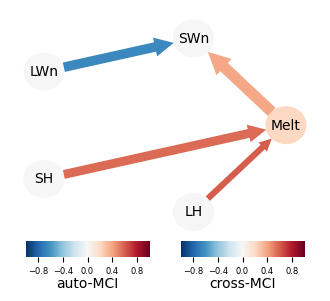

In [92]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/1975_2014/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [93]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [94]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.20819,0.0
1,Melt,SWn,0,-->,0.38365,36.0
2,Melt,SH,0,<--,0.56252,29.0
3,Melt,LH,0,<--,0.60616,20.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.64747,31.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [95]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

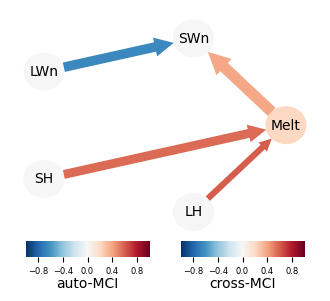

In [96]:
# Read in and plot
data = np.load(save_name, allow_pickle=True)

val_matrix = data['val_matrix']
graph = data['graph']
link_width = data['link_width']
var_names = data['var_names'].tolist()

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=val_matrix,  # Use the color matrix across all lags, including lag=0
    graph=graph,  # Use the most frequent link type for each lag, including lag=0
    var_names=var_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_width,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

In [54]:
# ===== Save contemporaneous strengths (lag=0) regardless of direction =====
pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}   # anything not '' counts as a detected contemporaneous link

# Infer number of members from any stored list at lag 0
# (fall back to 50 if unavailable, but your lists should have length 50)
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

out = {}

for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    # Get lists across members; guard if a key is missing
    types_ij   = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji   = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij  = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji  = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    sym_strength = np.full(n_members, np.nan, dtype=float)

    for k in range(n_members):
        s_list = []
        if types_ij[k] in valid_types and np.isfinite(streng_ij[k]):
            s_list.append(streng_ij[k])
        if types_ji[k] in valid_types and np.isfinite(streng_ji[k]):
            s_list.append(streng_ji[k])

        # mean absolute strength across whatever directions were detected this member
        if s_list:
            sym_strength[k] = float(np.mean(s_list))  # could use max(s_list) if you prefer

    out[f'{a}_to_{b}_lag0_anydir'] = sym_strength

# (Optional) also save direction tallies per member for auditing
dir_counts = {}
for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]
    types_ij = link_types_by_lag[lag0].get((i, j), [''] * n_members)
    types_ji = link_types_by_lag[lag0].get((j, i), [''] * n_members)
    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/lens2_1985_2014_contemp_strengths_anydir_SWn_SH_LH_Melt_lag0.npz'
np.savez(
    save_path,
    **out,
    **dir_counts,
    meta=np.array([
        "Definition: per-member mean |cross-MCI| at lag=0 across any detected direction "
        "(i→j and/or j→i); NaN = no contemporaneous link detected in either direction.",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths (any direction) to: {save_path}")

Saved contemporaneous strengths (any direction) to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/lens2_1985_2014_contemp_strengths_anydir_SWn_SH_LH_Melt_lag0.npz


In [55]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_anydir']
SH_strength  = data['SH_to_Melt_lag0_anydir']
LH_strength  = data['LH_to_Melt_lag0_anydir']

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")
print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")
print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))

SWn-Melt strengths: [0.38278513 0.36353755 0.20382521 0.63546748        nan 0.48042771
 0.38020969 0.35098121 0.54611541        nan 0.49387498 0.47790198
 0.34399679 0.1945586  0.25726883 0.25494284 0.45268706        nan
 0.35124015        nan 0.672493   0.24263669        nan 0.57208919
 0.30538314        nan 0.28492152 0.53757955        nan        nan
 0.27677669 0.28914527 0.38413276 0.36069933 0.42688215 0.36151185
        nan 0.35882342 0.30635057 0.24403454 0.41409592 0.62948084
 0.33852879 0.31561488 0.27447966 0.45332821 0.31629846 0.33559334
 0.50246067        nan]
Mean: 0.38432902701046856
Number of valid detections: 40

SH-Melt strengths: [0.44757799 0.49572794 0.43976209 0.54213886 0.67534069 0.65407495
 0.37489742 0.6632534  0.53822984 0.6837326  0.41417533 0.59578396
 0.36677206 0.50733316 0.50831508 0.38406818 0.59668821 0.75378533
 0.58530484 0.72491539 0.44430246 0.49610841 0.79565258 0.7005738
 0.55952828 0.73242147 0.68253325 0.31814772 0.59100861 0.65207831
 0.578746

In [97]:
# ===== Save contemporaneous strengths (lag=0) for the most-frequent link type =====
pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}  # contemporaneous link encodings

# Infer number of members
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

def consolidate_type(t_ij, t_ji):
    """Pick a single contemporaneous type for this member between vars i and j."""
    # Prefer explicit types; if both present but mismatch, pick a stable rule:
    # If either is undirected, treat as undirected; else prefer '-->' or '<--' if present.
    if t_ij in valid_types and t_ji in valid_types:
        if ('o-o' in (t_ij, t_ji)) or ('x-x' in (t_ij, t_ji)):
            return 'o-o' if 'o-o' in (t_ij, t_ji) else 'x-x'
        # If both are directed but inconsistent, prefer t_ij (stable, deterministic)
        return t_ij
    if t_ij in valid_types:
        return t_ij
    if t_ji in valid_types:
        # Map the (j,i) direction into the canonical i–j viewpoint:
        # If (j,i) shows '-->' that means j→i, i.e., '<--' for (i,j)
        if t_ji == '-->':
            return '<--'
        if t_ji == '<--':
            return '-->'
        return t_ji  # 'o-o' or 'x-x'
    return ''  # no contemporaneous link detected

# Priority for final tie-break if needed
type_priority = ['-->', '<--', 'o-o', 'x-x']

out = {}
dir_counts = {}
mf_type_meta = {}
mf_type_counts = {}
mf_type_mean_strength = {}

for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    types_ij  = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji  = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    # Per-member consolidated type (one of '-->','<--','o-o','x-x','')
    cons_types = np.array(
        [consolidate_type(types_ij[k], types_ji[k]) for k in range(n_members)],
        dtype='U3'
    )

    # Count frequencies among *detected* types (exclude '')
    counts = {t: int(np.sum(cons_types == t)) for t in valid_types}

    # If no detections at all, keep all-NaN and record 'none'
    if sum(counts.values()) == 0:
        out[f'{a}_to_{b}_lag0_mostfreq'] = np.full(n_members, np.nan, dtype=float)
        mf_type_meta[f'{a}_{b}_mostfreq_type'] = 'none'
        mf_type_counts[f'{a}_{b}_counts'] = counts
        mf_type_mean_strength[f'{a}_{b}_type_means'] = {t: np.nan for t in valid_types}
        # Keep auditing arrays
        dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
        dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')
        continue

    # Candidate types with max count
    max_count = max(counts.values())
    tied = [t for t, c in counts.items() if c == max_count and c > 0]

    # For tie-break: compute mean |strength| across members that *have that type*
    def member_strength_for_type(k, t):
        if t == '-->':  # i -> j
            return streng_ij[k] if np.isfinite(streng_ij[k]) else np.nan
        if t == '<--':  # j -> i
            return streng_ji[k] if np.isfinite(streng_ji[k]) else np.nan
        if t in ('o-o', 'x-x'):
            # mean of available directions (your prior choice)
            vals = []
            if np.isfinite(streng_ij[k]): vals.append(streng_ij[k])
            if np.isfinite(streng_ji[k]): vals.append(streng_ji[k])
            return np.mean(vals) if len(vals) else np.nan
        return np.nan

    type_means = {}
    for t in valid_types:
        idx = np.where(cons_types == t)[0]
        if idx.size == 0:
            type_means[t] = np.nan
        else:
            vals = [member_strength_for_type(k, t) for k in idx]
            vals = np.array(vals, dtype=float)
            type_means[t] = float(np.nanmean(np.abs(vals))) if np.isfinite(vals).any() else np.nan

    if len(tied) > 1:
        # Prefer the one with larger mean |strength|
        means_tied = {t: (type_means[t] if np.isfinite(type_means[t]) else -np.inf) for t in tied}
        best_mean = max(means_tied.values())
        tied_best = [t for t, m in means_tied.items() if m == best_mean]
        if len(tied_best) == 1:
            chosen = tied_best[0]
        else:
            # Final deterministic priority
            for t in type_priority:
                if t in tied_best:
                    chosen = t
                    break
    else:
        chosen = tied[0]

    # Build the per-member strength vector ONLY for the chosen type
    strengths_mf = np.full(n_members, np.nan, dtype=float)
    for k in range(n_members):
        if cons_types[k] == chosen:
            strengths_mf[k] = member_strength_for_type(k, chosen)

    out[f'{a}_to_{b}_lag0_mostfreq'] = strengths_mf
    mf_type_meta[f'{a}_{b}_mostfreq_type'] = chosen
    mf_type_counts[f'{a}_{b}_counts'] = counts
    mf_type_mean_strength[f'{a}_{b}_type_means'] = type_means

    # (Optional) keep raw type audits like before
    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

# ==== Save ====
save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/lens2_1975_2014_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_rmmontrend.npz'
np.savez(
    save_path,
    **out,
    **dir_counts,
    mf_type=np.array(mf_type_meta, dtype=object),
    mf_counts=np.array(mf_type_counts, dtype=object),
    mf_type_means=np.array(mf_type_mean_strength, dtype=object),
    meta=np.array([
        "Definition: per-member |cross-MCI| at lag=0 ONLY for the ensemble's most-frequent"
        " contemporaneous link type (among '-->','<--','o-o','x-x') per pair;"
        " members not matching that type are NaN.",
        "Tie-breaks: higher mean |strength| across tied types, then priority ['-->','<--','o-o','x-x'].",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths (most frequent type) to: {save_path}")

Saved contemporaneous strengths (most frequent type) to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/lens2_1975_2014_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_rmmontrend.npz


In [98]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_mostfreq']
SH_strength  = data['SH_to_Melt_lag0_mostfreq']
LH_strength  = data['LH_to_Melt_lag0_mostfreq']

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Min:", np.nanmin(SWn_strength))
print("Max:", np.nanmax(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")
print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Min:", np.nanmin(SH_strength))
print("Max:", np.nanmax(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")
print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Min:", np.nanmin(LH_strength))
print("Max:", np.nanmax(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))

SWn-Melt strengths: [0.33167383 0.41307657 0.36187134 0.42863973        nan 0.46115135
 0.30002534 0.39664488 0.55695894        nan        nan 0.46249749
        nan 0.27112991 0.31242707 0.34372858 0.4613186         nan
 0.47245873        nan 0.49851874 0.30336962 0.3219763         nan
 0.30187331 0.30212465 0.38285264        nan 0.47310968 0.27552457
 0.21748966 0.28451476        nan 0.43459084 0.41374129 0.45944098
 0.21237074 0.33620664 0.45703439        nan 0.44979275 0.58396959
        nan 0.37073454 0.38536611        nan        nan 0.48462098
        nan 0.28841974]
Mean: 0.38364569167753326
Min: 0.21237073674942675
Max: 0.5839695947036727
Number of valid detections: 36

SH-Melt strengths: [       nan 0.64298727 0.55721151        nan 0.61174355        nan
        nan        nan 0.57793545        nan 0.53337419 0.54598685
 0.38051266        nan 0.50764482 0.49943378 0.54671555 0.56513076
 0.55776363 0.77571422        nan        nan        nan 0.69286432
        nan 0.58897818 0.6

##### without seasonal cycle, max_lag=12, pc_alpha=None

In [99]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = None
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('1975-01-01','2014-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [100]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [101]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

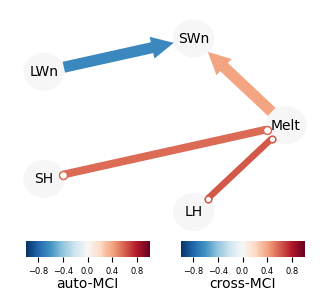

In [102]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/1975_2014/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [103]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [104]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.40529,41.0
2,Melt,SH,0,o-o,0.56843,29.0
3,Melt,LH,0,o-o,0.61975,24.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.64701,41.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [105]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))